# Analysis of the vaccination sweep

This notebook reads `results/sweep_results.csv` (produced by `run_experiment.py`) and produces the
tables and figures used in the report.

**Setup of the experiment:** SIR model on networks of 300 people with about 6 contacts each, recovery
rate gamma = 0.1, and 10% of the population vaccinated before the outbreak. We compare three network
types (random, small-world, scale-free) and four strategies (none, random, degree, betweenness) over
seven transmission probabilities (beta), with 30 repetitions per combination.

**Outcome measures:** `final_size` is the fraction of the population that was infected
(vaccinated people are not counted), `peak_infected` is the largest number infected at once.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results/sweep_results.csv")
STRATEGIES = ["none", "random", "degree", "betweenness"]
TOPOLOGIES = ["random", "small_world", "scale_free"]
COLOURS = {"none": "#8a8985", "random": "#2a78d6", "degree": "#eb6834", "betweenness": "#1baf7a"}
LABELS = {"random": "Random", "small_world": "Small-world", "scale_free": "Scale-free"}

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

print(df.shape)
print("repetitions per combination:", df.groupby(["topology", "strategy", "beta"]).size().unique())
df.head()

(2520, 8)
repetitions per combination: [30]


,topology,strategy,beta,replication,final_size,peak_infected,time_to_peak,duration
0,random,none,0.02,0,0.010000,3,7,15
1,random,none,0.02,1,0.043333,4,9,45
2,random,none,0.02,2,0.016667,3,14,20
3,random,none,0.02,3,0.006667,1,0,15
4,random,none,0.02,4,0.013333,3,3,27


## 1. Final epidemic size at beta = 0.10

Mean fraction of the population infected, with a 95% confidence interval over the 30 repetitions.

In [2]:
BETA = 0.10
d = df[np.isclose(df.beta, BETA)]
g = d.groupby(["topology", "strategy"]).final_size
summary = pd.DataFrame({"mean": g.mean(), "ci95": 1.96 * g.std() / np.sqrt(g.count())}).reset_index()

table = summary.pivot(index="topology", columns="strategy", values="mean")[STRATEGIES].loc[TOPOLOGIES]
table.index = [LABELS[t] for t in table.index]
table.round(3)

strategy,none,random,degree,betweenness
Random,0.829,0.668,0.661,0.768
Small-world,0.838,0.587,0.576,0.435
Scale-free,0.841,0.679,0.218,0.253


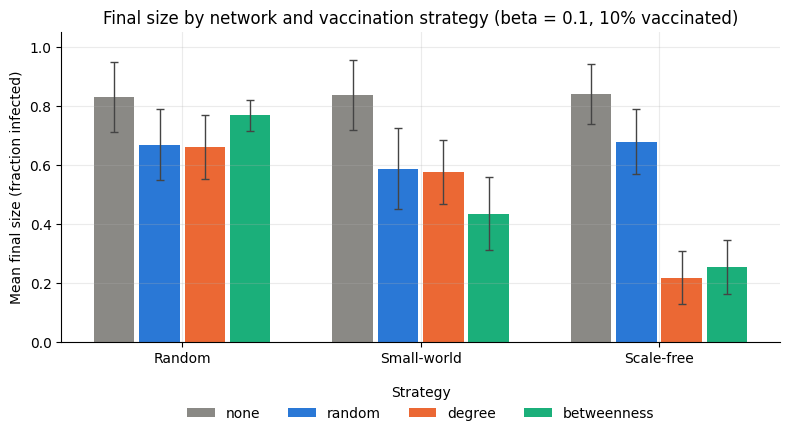

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
width = 0.19
x = np.arange(len(TOPOLOGIES))
for i, s in enumerate(STRATEGIES):
    rows = summary[summary.strategy == s].set_index("topology").loc[TOPOLOGIES]
    ax.bar(x + (i - 1.5) * width, rows["mean"], width - 0.02, yerr=rows["ci95"],
           color=COLOURS[s], label=s, capsize=3, error_kw={"linewidth": 1, "ecolor": "#444"})
ax.set_xticks(x)
ax.set_xticklabels([LABELS[t] for t in TOPOLOGIES])
ax.set_ylabel("Mean final size (fraction infected)")
ax.set_ylim(0, 1.05)
ax.set_title(f"Final size by network and vaccination strategy (beta = {BETA}, 10% vaccinated)")
ax.legend(title="Strategy", ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.1), frameon=False)
fig.tight_layout()
fig.savefig("results/analysis_final_size_by_strategy.png", dpi=150)
plt.show()

**Reading the chart.** On the scale-free network, vaccinating the best-connected people (degree or
betweenness) cuts the final size from about 0.84 to about 0.22-0.25, far more than vaccinating at
random (0.68). On the small-world network, targeting also helps (betweenness 0.44 vs random 0.59), and
on the random network vaccination helps less (0.83 with no vaccination, 0.66-0.77 with any strategy) and targeting is no better than random. The error bars are wide (30 repetitions of a random
process), so differences smaller than about 0.1 should not be over-interpreted. For example degree vs
random vaccination on the random network is not a real difference.

## 2. How the result changes with beta

Final size against the transmission probability, one panel per network.

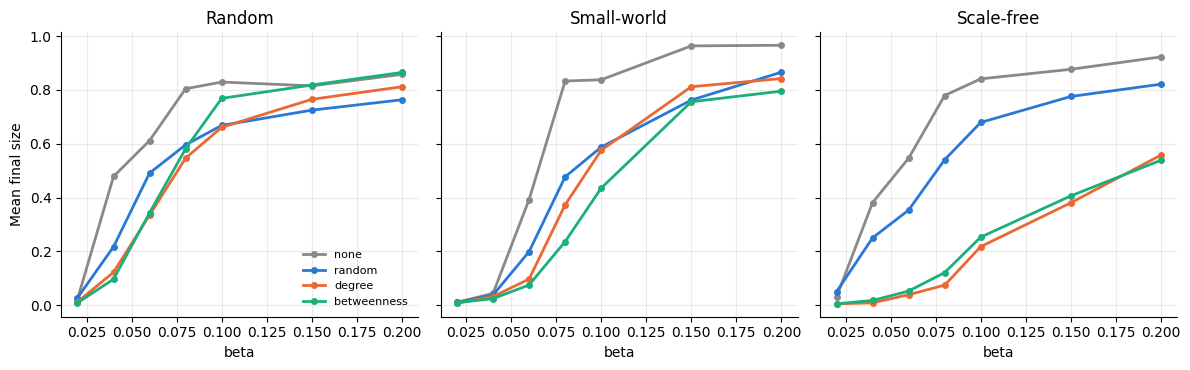

In [4]:
m = df.groupby(["topology", "strategy", "beta"]).final_size.mean().reset_index()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, t in zip(axes, TOPOLOGIES):
    for s in STRATEGIES:
        r = m[(m.topology == t) & (m.strategy == s)]
        ax.plot(r.beta, r.final_size, marker="o", markersize=4, linewidth=2, color=COLOURS[s], label=s)
    ax.set_title(LABELS[t])
    ax.set_xlabel("beta")
axes[0].set_ylabel("Mean final size")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig("results/analysis_final_size_vs_beta.png", dpi=150)
plt.show()

**Reading the chart.** Without vaccination the epidemic takes off from about beta = 0.04 on the random
and scale-free networks and from about 0.08 on the small-world network (where contacts are clustered). On the scale-free network targeted vaccination keeps the final size low over the whole range
(still about 0.55 at beta = 0.20, against 0.92 with no vaccination). At high beta the benefit shrinks on
the random network, where every strategy ends up between 0.76 and 0.87.

## 3. Reduction relative to no vaccination (beta = 0.10)

In [5]:
base = summary[summary.strategy == "none"].set_index("topology")["mean"]
red = summary.pivot(index="topology", columns="strategy", values="mean")[STRATEGIES[1:]].loc[TOPOLOGIES]
red = (1 - red.div(base.loc[TOPOLOGIES], axis=0)) * 100
red.index = [LABELS[t] for t in red.index]
red.round(0).astype(int).astype(str) + "%" 

strategy,random,degree,betweenness
Random,19%,20%,7%
Small-world,30%,31%,48%
Scale-free,19%,74%,70%


## 4. Do outbreaks take off, and how big are they when they do?

On a network an outbreak can die out almost immediately if the first infected person recovers before
passing the disease on. We call a run a *major outbreak* if more than 10% of the population was infected.
Vaccination can help in two ways: it can make major outbreaks less likely, or make them smaller.

In [6]:
d = d.assign(major=d.final_size > 0.10)
prob = d.groupby(["topology", "strategy"]).major.mean().unstack()[STRATEGIES].loc[TOPOLOGIES]
size = d[d.major].groupby(["topology", "strategy"]).final_size.mean().unstack()[STRATEGIES].loc[TOPOLOGIES]
prob.index = size.index = [LABELS[t] for t in TOPOLOGIES]
print("Share of runs that became major outbreaks:")
display(prob.round(2))
print("Mean final size of the major outbreaks only:")
display(size.round(2))

Share of runs that became major outbreaks:


strategy,none,random,degree,betweenness
Random,0.87,0.80,0.83,0.97
Small-world,0.87,0.70,0.77,0.63
Scale-free,0.90,0.83,0.43,0.50


Mean final size of the major outbreaks only:


strategy,none,random,degree,betweenness
Random,0.96,0.83,0.79,0.79
Small-world,0.97,0.83,0.74,0.67
Scale-free,0.93,0.81,0.49,0.50


**Reading the tables.** On the scale-free network, degree and betweenness vaccination do both: the chance
of a major outbreak falls from about 0.90 to 0.43-0.50, and the outbreaks that do happen are about half
the size (about 0.49 against 0.93). On the random network the chance of a major outbreak barely changes (0.80-0.97), so the benefit comes
from smaller outbreaks only. On the small-world network it falls moderately (0.87 to 0.63-0.77).

## 5. Peak number infected (beta = 0.10)

In [7]:
peak = d.groupby(["topology", "strategy"]).peak_infected.mean().unstack()[STRATEGIES].loc[TOPOLOGIES]
peak.index = [LABELS[t] for t in TOPOLOGIES]
peak.round(0).astype(int)

strategy,none,random,degree,betweenness
Random,125,91,79,90
Small-world,82,48,41,28
Scale-free,128,98,16,20


Peak infections follow the same pattern as final size. Targeted vaccination on the scale-free network
lowers the peak from about 128 people to about 16-20 (out of 300), which matters for hospital capacity.

## Summary

* Which people are vaccinated matters much more than how many, on networks with a few highly connected
  people (scale-free): vaccinating 10% of the best-connected people does more than vaccinating at random.
* On the random network, where everyone has a similar number of contacts, there is little to gain from
  targeting.
* Results are noisy. Each combination is 30 runs, many of which die out early, so small differences are
  not reliable.
* Limitations: only 300 people, one vaccination coverage (10%), a fully effective and instant vaccine,
  and a static network. See the README and report for discussion.